<a href="https://colab.research.google.com/github/ZKhan2005/Fine-Tuning-Pro/blob/main/Fine_Tuning_Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q google-generativeai

In [2]:
import google.generativeai as genai

In [3]:
from google.colab import userdata
genai.configure(api_key=userdata.get('GOOGLE_API_KEY'))


In [4]:
for i, m in zip(range(5), genai.list_tuned_models()):
  print(m.name)

tunedModels/generate-num-6879


In [5]:
base_model = [
    m for m in genai.list_models()
    if "createTunedModel" in m.supported_generation_methods and
    "flash" in m.name][0]
base_model

Model(name='models/gemini-1.5-flash-001-tuning',
      base_model_id='',
      version='001',
      display_name='Gemini 1.5 Flash 001 Tuning',
      description=('Version of Gemini 1.5 Flash that supports tuning, our fast and versatile '
                   'multimodal model for scaling across diverse tasks, released in May of 2024.'),
      input_token_limit=16384,
      output_token_limit=8192,
      supported_generation_methods=['generateContent', 'countTokens', 'createTunedModel'],
      temperature=1.0,
      max_temperature=2.0,
      top_p=0.95,
      top_k=64)

In [6]:
import random

name = f'generate-num-{random.randint(0,10000)}'
operation = genai.create_tuned_model(
    # You can use a tuned model here too. Set `source_model="tunedModels/..."`
    source_model=base_model.name,
    training_data=[
        {
             'text_input': '1',
             'output': '2',
        },{
             'text_input': '3',
             'output': '4',
        },{
             'text_input': '-3',
             'output': '-2',
        },{
             'text_input': 'twenty two',
             'output': 'twenty three',
        },{
             'text_input': 'two hundred',
             'output': 'two hundred one',
        },{
             'text_input': 'ninety nine',
             'output': 'one hundred',
        },{
             'text_input': '8',
             'output': '9',
        },{
             'text_input': '-98',
             'output': '-97',
        },{
             'text_input': '1,000',
             'output': '1,001',
        },{
             'text_input': '10,100,000',
             'output': '10,100,001',
        },{
             'text_input': 'thirteen',
             'output': 'fourteen',
        },{
             'text_input': 'eighty',
             'output': 'eighty one',
        },{
             'text_input': 'one',
             'output': 'two',
        },{
             'text_input': 'three',
             'output': 'four',
        },{
             'text_input': 'seven',
             'output': 'eight',
        }
    ],
    id = name,
    epoch_count = 100,
    batch_size=4,
    learning_rate=0.001,
)

In [7]:
model = genai.get_tuned_model(f'tunedModels/{name}')

model

TunedModel(name='tunedModels/generate-num-8447',
           source_model='models/gemini-1.5-flash-001-tuning',
           base_model='models/gemini-1.5-flash-001-tuning',
           display_name='',
           description='',
           temperature=1.0,
           top_p=0.95,
           top_k=64,
           state=<State.CREATING: 1>,
           create_time=datetime.datetime(2025, 2, 12, 14, 42, 17, 417930, tzinfo=datetime.timezone.utc),
           update_time=datetime.datetime(2025, 2, 12, 14, 43, 22, 272638, tzinfo=datetime.timezone.utc),
           tuning_task=TuningTask(start_time=datetime.datetime(2025, 2, 12, 14, 42, 18, 50040, tzinfo=datetime.timezone.utc),
                                  complete_time=None,
                                  snapshots=[...],
                                  hyperparameters=Hyperparameters(epoch_count=100,
                                                                  batch_size=4,
                                                            

In [8]:
model.state

<State.CREATING: 1>

In [9]:
operation.metadata

tuned_model: "tunedModels/generate-num-8447"
total_steps: 375

In [10]:
import time

for status in operation.wait_bar():
  time.sleep(3)

  0%|          | 0/375 [00:00<?, ?it/s]

In [11]:
# operation.cancel()

<Axes: xlabel='epoch', ylabel='mean_loss'>

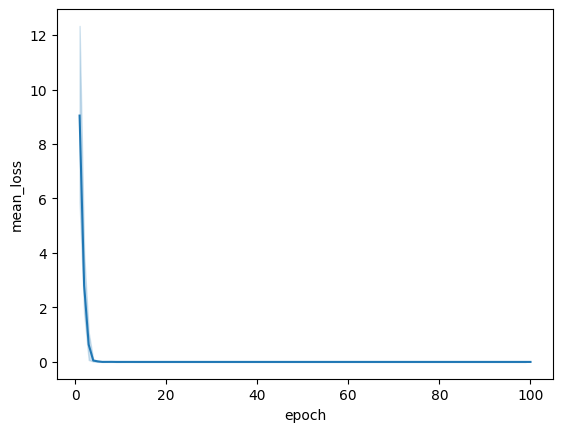

In [ ]:
import pandas as pd
import seaborn as sns

model = operation.result()

import pandas as pd
import seaborn as sns

model = operation.result()

snapshots = pd.DataFrame(model.tuning_task.snapshots)

sns.lineplot(data=snapshots, x = 'epoch', y='mean_loss')

In [12]:
model = genai.GenerativeModel(model_name=f'tunedModels/{name}')

In [13]:
result = model.generate_content('55')
result.text

'56'

In [14]:
result = model.generate_content('123455')
result.text

ERROR:tornado.access:503 POST /v1beta/tunedModels/generate-num-8447:generateContent?%24alt=json%3Benum-encoding%3Dint (127.0.0.1) 1929.65ms
ERROR:tornado.access:503 POST /v1beta/tunedModels/generate-num-8447:generateContent?%24alt=json%3Benum-encoding%3Dint (127.0.0.1) 913.63ms
ERROR:tornado.access:503 POST /v1beta/tunedModels/generate-num-8447:generateContent?%24alt=json%3Benum-encoding%3Dint (127.0.0.1) 839.32ms
ERROR:tornado.access:503 POST /v1beta/tunedModels/generate-num-8447:generateContent?%24alt=json%3Benum-encoding%3Dint (127.0.0.1) 1200.07ms


'123456'

In [15]:
result = model.generate_content('four')
result.text

'five'

In [16]:
result = model.generate_content('quatre') # French 4
result.text                               # French 5 is "cinq"

'cinq'

In [ ]:
result = model.generate_content('III')    # Roman numeral 3
result.text                               # Roman numeral 4 is IV

'IV'

In [ ]:
result = model.generate_content('七')  # Japanese 7
result.text                            # Japanese 8 is 八!

'八'

In [ ]:
model = genai.get_tuned_model(f'tunedModels/{name}')

model.description

'This is my model.'

## DELETE THE MODAL

In [17]:
genai.delete_tuned_model(f'tunedModels/{name}')

# **the modal no longer exists:**

In [18]:
try:
  m = genai.get_tuned_model(f'tunedModels/{name}')
  print(m)
except Exception as e:
  print(f"{type(e)}: {e}")

<class 'google.api_core.exceptions.NotFound'>: 404 GET https://generativelanguage.googleapis.com/v1beta/tunedModels/generate-num-8447?%24alt=json%3Benum-encoding%3Dint: Tuned model tunedModels/generate-num-8447 does not exist.
